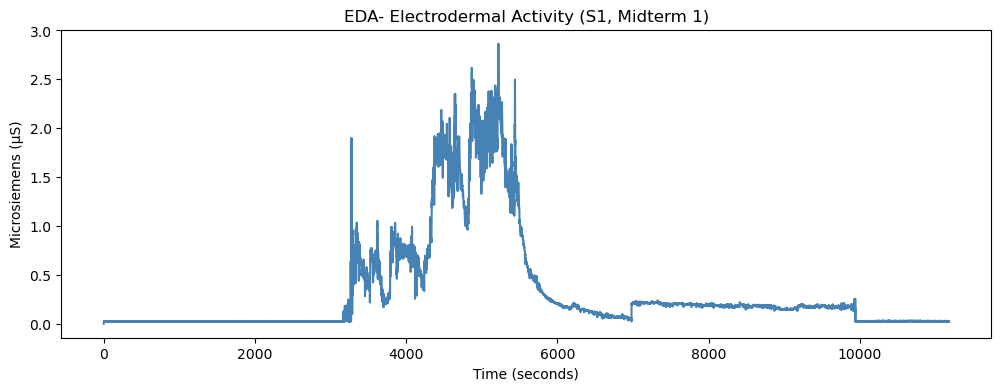

Duration: 186.3 minutes
Sampling rate: 4.0 Hz


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os 

base_path = r"C:\Users\munpa\OneDrive\Desktop\Projects\a-wearable-exam-stress-dataset-for-predicting-cognitive-performance-in-real-world-settings-1.0.0\a-wearable-exam\Data\Data\S1\Midterm 1"

eda = pd.read_csv(os.path.join(base_path, "EDA.csv"), header=None)

eda_fs = float(eda.iloc[1,0])
eda_signal = eda.iloc[2:, 0].reset_index(drop=True).astype(float) 

eda_time = [i / eda_fs for i in range(len(eda_signal))] 

plt.figure(figsize=(12, 4))
plt.plot(eda_time, eda_signal, color='steelblue')
plt.title('EDA- Electrodermal Activity (S1, Midterm 1)')
plt.xlabel('Time (seconds)')
plt.ylabel('Microsiemens (μS)')
plt.show()

print(f"Duration: {len(eda_signal)/eda_fs/60:.1f} minutes")
print(f"Sampling rate: {eda_fs} Hz")




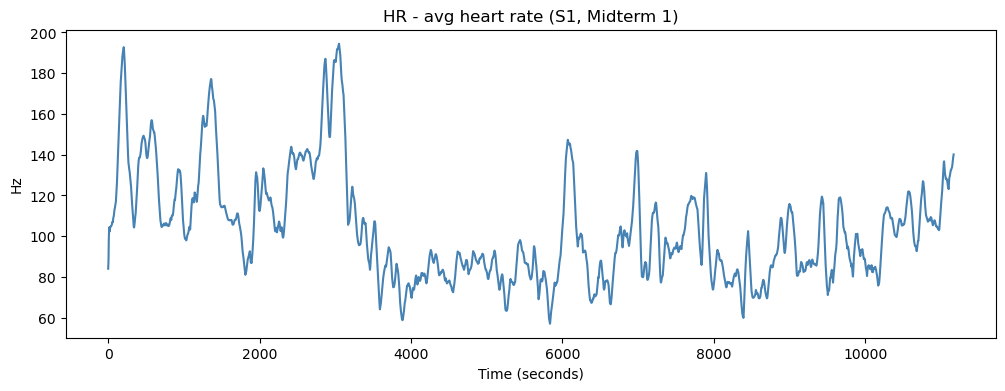

In [5]:
hr = pd.read_csv(os.path.join(base_path, "HR.csv"), header=None) 

hr_fs = float(hr.iloc[1, 0])
hr_signal = hr.iloc[2:, 0].reset_index(drop=True).astype(float) 

hr_time = [i / hr_fs for i in range(len(hr_signal))]

plt.figure(figsize=(12, 4))
plt.plot(hr_time, hr_signal, color='steelblue')
plt.title('HR - avg heart rate (S1, Midterm 1)')
plt.xlabel('Time (seconds)')
plt.ylabel('Hz')
plt.show()

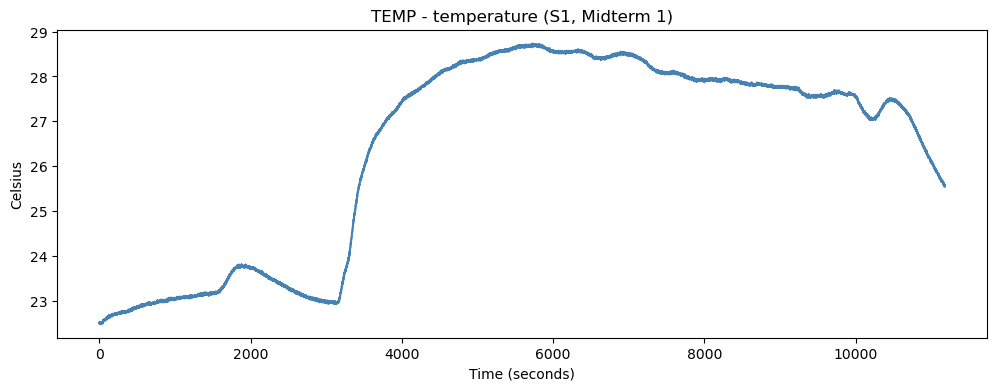

In [6]:
temp = pd.read_csv(os.path.join(base_path, "TEMP.csv"), header=None)

temp_fs = float(temp.iloc[1, 0])
temp_signal = temp.iloc[2:, 0].reset_index(drop=True).astype(float)

temp_time = [i / temp_fs for i in range(len(temp_signal))]

plt.figure(figsize=(12, 4))
plt.plot(temp_time, temp_signal, color='steelblue')
plt.title('TEMP - temperature (S1, Midterm 1)')
plt.xlabel('Time (seconds)')
plt.ylabel('Celsius')
plt.show()




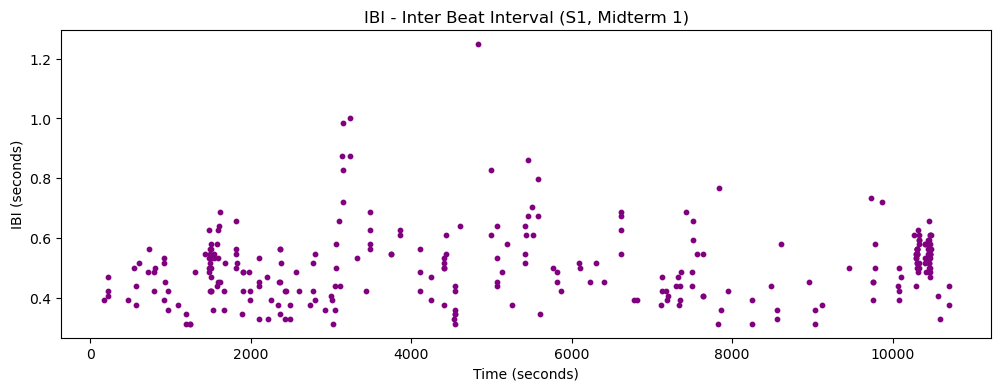

RMSSD:  0.1254 seconds


In [9]:
ibi = pd.read_csv(os.path.join(base_path, "IBI.csv"), header=None, skiprows=1) 
ibi_time = ibi.iloc[:, 0].astype(float)
ibi_values = ibi.iloc[:, 1].astype(float) 

plt.figure(figsize=(12, 4))
plt.scatter(ibi_time, ibi_values, color='purple', s=10)
plt.title('IBI - Inter Beat Interval (S1, Midterm 1)')
plt.xlabel('Time (seconds)')
plt.ylabel('IBI (seconds)')
plt.show()


#HRV calc
succ_diff = ibi_values.diff().dropna()
rmssd = (succ_diff**2).mean()**0.5
print(f"RMSSD: {rmssd: .4f} seconds")
